# Property Valuation — Lagos, Nigeria

**Business question.** Predict Lagos residential sale prices accurately enough for buyers, estate agents, and mortgage lenders.

**Pipeline:** business question → data & EDA → feature engineering → OLS + GBM → validation → deployment.

**Data:** [thedevastator/investigating-housing-prices-in-lagos-nigeria](https://www.kaggle.com/datasets/thedevastator/investigating-housing-prices-in-lagos-nigeria) — 9,784 sale listings.

## 1. Setup

In [1]:
import re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0); sns.set_style('whitegrid')

## 2. Load + parse

In [2]:
df = pd.read_csv('data/sale_2.csv').drop(columns=['Unnamed: 0'], errors='ignore')
df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(',','').str.replace('₦',''), errors='coerce')
df = df.dropna(subset=['Price'])
df = df[(df['Price'] >= 5e5) & (df['Price'] <= 5e9)]  # plausible range, NGN

def parse_bedrooms(s):
    m = re.search(r'(\d+)\s*bedroom', str(s).lower())
    return int(m.group(1)) if m else 0

def parse_type(s):
    s = str(s).lower()
    for t in ['land','duplex','flat','apartment','bungalow','house','terrace','semi-detached','detached','penthouse']:
        if t in s: return t
    return 'other'

df['bedrooms'] = df['Property_name'].apply(parse_bedrooms)
df['ptype'] = df['Property_name'].apply(parse_type)
df['log_price'] = np.log1p(df['Price'])
print(f'rows: {len(df):,}, neighborhoods: {df["Neighboorhood"].nunique()}, types: {df["ptype"].nunique()}')
df[['Price','bedrooms','ptype','Neighboorhood']].head()

rows: 9,607, neighborhoods: 41, types: 6


,Price,bedrooms,ptype,Neighboorhood
0,2500000,0,land,Ibeju-Lekki
1,30000000,0,land,Ikeja
2,3500000000,3,land,VI
3,340000000,5,duplex,Lekki
4,28000000,3,flat,Igando


## 3. EDA

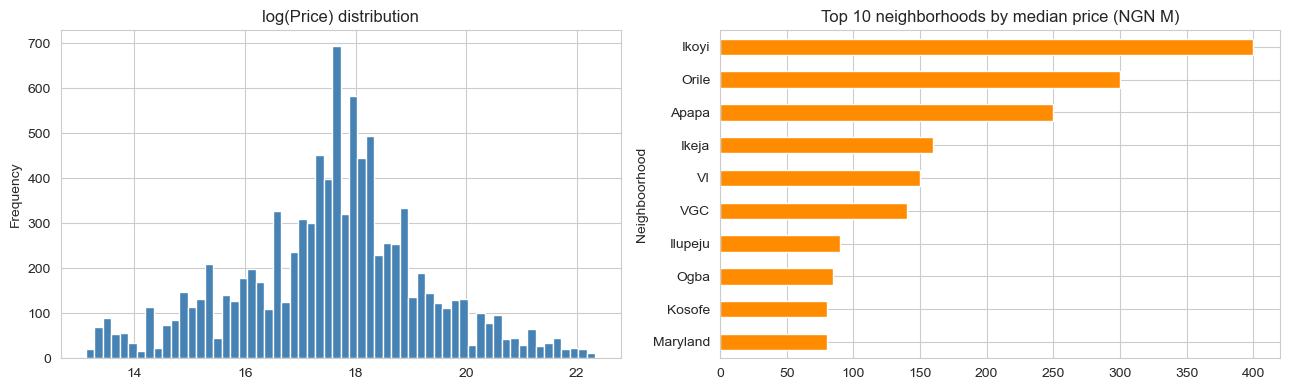

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['log_price'].plot(kind='hist', bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('log(Price) distribution')
top10_nb = df.groupby('Neighboorhood')['Price'].median().nlargest(10)
(top10_nb/1e6).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 neighborhoods by median price (NGN M)'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

In [4]:
# Median price by property type
df.groupby('ptype')['Price'].agg(['count','median']).sort_values('median', ascending=False).head(10)

,count,median
ptype,,
other,314,177500000.0
duplex,2699,70000000.0
house,589,55000000.0
flat,1272,37500000.0
bungalow,445,20000000.0
land,4288,20000000.0


## 4. Modeling

In [5]:
# Keep only top neighborhoods (rare ones become 'Other')
top_nb = df['Neighboorhood'].value_counts().head(15).index
df['nb'] = np.where(df['Neighboorhood'].isin(top_nb), df['Neighboorhood'], 'Other')
X = pd.get_dummies(df[['bedrooms','ptype','nb']], drop_first=True).astype(float)
y = df['log_price']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0)
print(f'features: {X.shape[1]}, train: {Xtr.shape}, test: {Xte.shape}')

features: 21, train: (7685, 21), test: (1922, 21)


In [6]:
# OLS
Xtr_c = sm.add_constant(Xtr.astype(float))
Xte_c = sm.add_constant(Xte.astype(float))
ols = sm.OLS(ytr, Xtr_c).fit()
ols_pred = ols.predict(Xte_c)
print(f'OLS R²={r2_score(yte, ols_pred):.3f}')

OLS R²=0.510


In [7]:
gbm = GradientBoostingRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, random_state=0).fit(Xtr, ytr)
gbm_pred = gbm.predict(Xte)
print(f'GBM R²={r2_score(yte, gbm_pred):.3f}')

GBM R²=0.574


## 5. Validation

In [8]:
def metrics(y_log, yhat_log):
    y, yhat = np.expm1(y_log), np.expm1(yhat_log)
    return {'R² (log)': r2_score(y_log, yhat_log),
            'MAE (log)': mean_absolute_error(y_log, yhat_log),
            'MAPE (raw)': mean_absolute_percentage_error(y, yhat),
            'RMSE (raw NGN)': float(np.sqrt(mean_squared_error(y, yhat)))}

scores = pd.DataFrame([{'model':'OLS', **metrics(yte, ols_pred)},
                       {'model':'GBM', **metrics(yte, gbm_pred)}])
scores.sort_values('R² (log)', ascending=False)

,model,R² (log),MAE (log),MAPE (raw),RMSE (raw NGN)
1,GBM,0.573596,0.768805,1.510989,3.660209e+08
0,OLS,0.510076,0.863630,1.779948,3.958935e+08


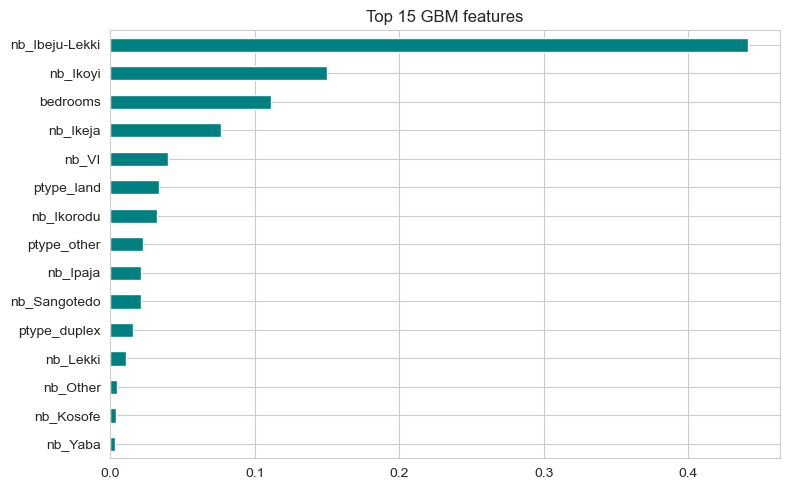

In [9]:
# Feature importances (top 15 from GBM)
fi = pd.Series(gbm.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', ax=ax, color='teal'); ax.invert_yaxis(); ax.set_title('Top 15 GBM features')
plt.tight_layout(); plt.show()

## 6. Deployment

- **API:** `POST /property-valuation` → estimated price + 80% interval given bedrooms, type, neighborhood.
- **Estate-agent dashboard:** distribution overlays per neighborhood, comparable-listings panel.
- **Refresh:** weekly crawl + retrain.

## 7. Business outcome

- Buyers and agents anchor pricing decisions on a model, not vibes.
- Lenders gain an explainable valuation reference.
- Pipeline extends trivially to Abuja, Ibadan, Port Harcourt with neighborhood-tagged data.